# Unified plotting for Laughter paper: Norwegian Folk Dancing Session

extract physiological measurements and audio from externally hosted data, import annotation files describing dance events and laughter, compose plots for paper

In [1]:
import sys
import os
import time

import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin as pg

import librosa

from scipy import interpolate

In [2]:
%load_ext autoreload
%autoreload 1
%aimport mh
%aimport rp2
%aimport viz
%aimport qex

In [3]:
 %reload_ext autoreload

# Import data constellation

In [4]:
Event = 'FolkDancing'
audio_loc ='../FolkDance/AV/Audio_exp/'
phys_dir ='../FolkDance/Equivital/'
misc_loc = './datain/'
data_out = './dataout/'
plot_loc = './plots/'

In [5]:
part_dets =  pd.read_csv('../FolkDance/Participants/background.csv',index_col=0)
Row_Order = ['PC705', 'LS401', 'AU813', 'LS402', 'AU807', 'WW504', 'WW501',
       'WW507', 'AU806', 'LS406', 'AU809', 'AU811', 'WW509'] #, 'VN203'
part_dets.loc[Row_Order,'What is your experience with Norwegian Folk Dancing in particular?']
# Norwegian folk dance
folk_sections = {'Experienced':['LS401','AU811'],
           'Familiar':['AU813','LS402','WW504','WW509'],
           'Unfamiliar':['PC705','AU807','WW501','WW507','AU806','LS406','AU809']} #    ,'AU826','AU819',]}

# Dancer
dancer_sections = {'Dancers':['WW504','AU811','AU809','WW501','LS401'],
           'Casual dancers':['AU813','LS402','LS406','WW509'],
           'Non-dancers':['PC705','AU807','WW507','AU806']} 



In [6]:

df_files = pd.DataFrame(columns=['PartID','NID','Performance','Segment','Signal','Measure','FileLoc'])
k = 0
for path, subdirs, files in os.walk(phys_dir+'Events/'):
    for f in files:
        fileloc = os.path.join(path, f)
        dets = f.split('_')
        measure = dets[-1]
        if measure.endswith('.csv'):
            measure = measure[:-4]
            signal = measure[-3:]
            if signal == 'ATA': signal = 'DATA'
            if signal == 'ESP': signal = 'RESP'
            if len(dets)==3:
                    df_files.loc[k,:] = {'PartID':dets[0],'NID':int(dets[0][2:5]),'Performance':'ChristmasParty','Segment':dets[1],'Signal':signal,'Measure':measure,'FileLoc':fileloc}
                    k+=1
PhysFiles = df_files.copy()
subfiles = df_files

In [7]:
df_allfeats = {}

Row_Order = ['PC705', 'LS401', 'AU813', 'LS402', 'AU807', 'WW504', 'WW501',
       'WW507', 'AU806', 'LS406', 'AU809', 'AU811', 'WW509']
players = Row_Order
sections = folk_sections
sect_labels = ['Experienced', 'Familiar', 'Unfamiliar']
section_pallet = {'Experienced':[0.5,0.5,0.5], 'Familiar':[0.2,0.2,0.2], 'Unfamiliar':'k'}
player_pallet = {}
collist = []
sectag = []
seccount = []
sectick = []
alist = []
i=0
for k in sections.keys():
    c = np.array(section_pallet[k])
    d_c = c/(1.25*len(sections[k])) #n_c = len(sections[k])
    c_i = 0
    sublist = []
    for s in sections[k]:
        if s in subfiles.PartID.values: 
            sublist.append(s)
            alist.append(s)
            player_pallet[s] = c - c_i*d_c # np.power(c,c_i/2)
            c_i+=1
    if len(sublist)>0:
        sectick.append(i)
        sectag.append(k) 
        i += len(sublist)/2
        seccount.append(i)
        i += len(sublist)/2
        i+=1
        for s in sublist: collist.append(s)
        collist.append(' ')
print([sectag,seccount,collist])



[['Experienced', 'Familiar', 'Unfamiliar'], [1.0, 5.0, 11.5], ['LS401', 'AU811', ' ', 'AU813', 'LS402', 'WW504', 'WW509', ' ', 'PC705', 'AU807', 'WW501', 'WW507', 'AU806', 'LS406', 'AU809', ' ']]


In [12]:
Event_timings  = pd.read_csv(misc_loc+'Folk_Dancing_Events_Tidied.csv')
instruction_timings = Event_timings.query('Trial_Type=="Instruction"').copy()
instruction_timings.reset_index(inplace=True,drop=True)
events_types = ['Demo','Practice','Music','Verbal','Applause']
eventType_pallet=dict(zip(events_types,['#94bbdf','#bbb0e4','#e9a2cc','#ff9d9d','#ca65be',])) #['#4d8f98','#4d8bce','#ca65be','#ff494c']
eventType_hatching=dict(zip(events_types,['*','.',None,'x','\\']))
eventType_code = dict(zip(['Demo','Practice','Music','Verbal','Applause'],['D','T','M','V','A']))
code_eventType = dict(zip(['D','T','M','V','A'],['Demo','Practice','Music','Verbal','Applause']))

dancings = Event_timings.query('Trial_Type in @events_types').copy()
dancings['DURATION'] = dancings['Dur']
dancings=dancings.query('Structure!="X"').copy()
dancings['Title']=dancings['LABEL']
dancings['LABEL']=dancings['Structure'] 

laughs = pd.read_csv(misc_loc+'Folk_Dance_Laughter_notes.csv')
laughs['Difficulty'] = laughs['Communicating difficulty']  # Communicating difficulty level (label: difficulty level) Communicating difficulty
laughs['Novelty'] =  laughs['Novelty and Surprise']
laughs['Negotiation'] =  laughs['Negociation']
laughs['Other'] = laughs['External']
laughs['InChatter'] = laughs['In Chatter']

who_hatch = { 'solo':'\\','few':'xx', 'subset':'xx','group':None}
whats = ['Mistake','Negotiation','Difficulty','Novelty','Joyful','Joke','Other','InChatter']
what_palette = dict(zip(whats,list(sns.color_palette("bright",len(whats)))))


In [15]:
Event_timings 

,TIME,LABEL,Structure,Terms,Description,StartTime,EndTime,Dur,Trial_Type
0,0.023220,Clapping,A0,NaN,NaN,0.023220,8.661043,8.637823,Applause
1,8.661043,Call to dance,V1,NaN,NaN,8.661043,32.531156,23.870113,Verbal
2,32.531156,Task: Find partner and place,T0,NaN,NaN,32.531156,92.276100,59.744943,Practice
3,92.276100,Instructor calls attention,V2,NaN,NaN,92.276100,120.929524,28.653424,Verbal
4,120.929524,Demo 1: Lead circle,D1,Default hold,"LR-FL hands, forward facing, circling in place",120.929524,126.409433,5.479909,Demo
5,126.409433,Attempts,T1,NaN,NaN,126.409433,151.556644,25.147211,Practice
6,135.836735,"Ins: Stepping 1-2, 1-2",I,NaN,NaN,135.836735,NaN,0.000000,Instruction
7,151.556644,Demo 2: close,D2,Parade Follow,"LR-FL hands, follow paraded around lead with R...",151.556644,157.524172,5.967528,Demo
8,157.524172,Attempts,T2,NaN,NaN,157.524172,207.516735,49.992562,Practice
9,183.971701,Ins: Stay on the spot,I,NaN,NaN,183.971701,NaN,0.000000,Instruction


# Session measurements from vests and audio¶


In [21]:
time_c = 'c_sTime'
concert = 'ChristmasParty'
piece = 'Dancing'
ylabs = ['ACC_Vert','ACC_Lat','ACC_Long','ACC_QoM']#,'normHR1bt','HR10bt','HRV10bt_ar','Respwave','Respdiff','Audio']

s_time = -10
e_time = Event_timings['TIME'].iloc[-1]
altT = np.arange(s_time,e_time ,0.01) #down sampling to 100Hz
df = pd.DataFrame(index = altT, columns = collist) #Row_Order)
all_sigs = {}
for t in ['ACC_Vert','ACC_Lat','ACC_Long','ACC_QoM']: all_sigs[t] = df.copy()
    
for partID in alist:
    row = subfiles.query('PartID==@partID and Signal=="ACC" and Segment == @piece').iloc[0]
    V = pd.read_csv(row['FileLoc'])
    V_seg=V.copy()
    V_seg.loc[:,'qom'] = np.sqrt(np.square(V_seg.loc[:,[ 'Vert Accelerometer','Lat Accelerometer','Long Accelerometer']].diff()).sum(axis=1)).rolling(128).mean()
    times = V_seg[time_c]
    f = interpolate.interp1d(times,V_seg['Vert Accelerometer'],kind = 'linear')    
    all_sigs['ACC_Vert'].loc[:,row['PartID']] = f(altT)
    f = interpolate.interp1d(times,V_seg['Lat Accelerometer'],kind = 'linear')    
    all_sigs['ACC_Lat'].loc[:,row['PartID']] = f(altT)
    f = interpolate.interp1d(times,V_seg['Long Accelerometer'],kind = 'linear')    
    all_sigs['ACC_Long'].loc[:,row['PartID']] = f(altT)
    f = interpolate.interp1d(times,V_seg['qom'],kind = 'linear')    
    all_sigs['ACC_QoM'].loc[:,row['PartID']] = f(altT)
        
# handing a distracting anomali
all_sigs['ACC_QoM'].loc[59.45:60.95,'AU811'] = all_sigs['ACC_QoM'].loc[59.45:60.95,'AU811'].min() 

for t in ['ACC_Vert','ACC_Lat','ACC_Long','ACC_QoM']: df_allfeats[t] = all_sigs[t].copy()

# respiration
df_feats = pd.DataFrame(index = altT,columns = collist)
sig = 'RespWave'
for partID in alist:
    row = subfiles.query('PartID==@partID and Signal=="RESP" and Segment == @piece').iloc[0]
    R = pd.read_csv(row['FileLoc'])  # currently this defaults to altEQCIBI before the original signal
    R.set_index('c_sTime',inplace=True)
    if len(V)>10:
        Breaths = rp2.breath_cycles(rp2.EQ_Inspiration_Extract(R['Breathing']),R['Breathing'])
        R['Breathing']= (R['Breathing']-R['Breathing'].median())/Breaths['IDepth'].quantile(0.15)
        f = interpolate.interp1d(R.index,R['Breathing'],fill_value='extrapolate')
        df_feats.loc[:,partID] = f(altT) 
df_allfeats[sig] = df_feats.copy()

# heart rate
df_feats = pd.DataFrame(index = altT,columns = collist)
sig = 'normHR1bt'
for partID in alist:
    row = subfiles.query('PartID==@partID and Signal=="IBI" and Segment == @piece').iloc[0]
    V = pd.read_csv(row['FileLoc'])  # currently this defaults to altEQCIBI before the original signal
    V = V.loc[V['Interbeat Interval (MS)']>0,:].copy()
    if len(V)>10:
        sig_t = V['c_sTime']
        sig_v = V['Interbeat Interval (MS)']
        IBI = mh.clean_IBI(sig_t,sig_v,activitytype='default')
        HR = mh.ibi_feats(IBI.index,IBI.IBI.values,altT)
        df_feats.loc[:,partID] = HR[sig].values
df_allfeats[sig] = df_feats.copy()

df_smoothed = df_feats.copy()
for partID in Row_Order:
    HR = df_smoothed[partID]
    cutHR = HR[HR.notna()]
    cutT = HR[HR.notna()].index
    f = interpolate.interp1d(cutT,cutHR.values,fill_value='extrapolate',kind= 'linear')
    df_smoothed[partID] = f(df_smoothed.index)
df_smoothed = df_smoothed.where(df_smoothed>-0.2, other=-0.2 ) #df[:] = np.where( mask, 30, df ) 
df_smoothed = df_smoothed.where(df_smoothed<1.5, other=1.5) #df[:] = np.where( mask, 30, df ) 
df_allfeats[sig+'_smoothed'] = df_smoothed.copy()

Clipped!


In [23]:
# Audio
aud_file = audio_loc + 'FolkDancing_w3_4800.mp3'
y, sr = librosa.load(aud_file)
rms =librosa.feature.rms(y=y, frame_length=256, hop_length=64, center=True, pad_mode='constant')
times = librosa.times_like(rms,sr = sr, hop_length=64)

buff = 0 # no buffer for this audio
C = librosa.cqt(y=y, sr=sr)
C_db = librosa.amplitude_to_db(np.abs(C), ref=np.max)
times = (-buff+np.arange(len(C_db[0]))*(times[-1])/len(C_db[0])).round(3)
pitchticks = np.arange(7,84,12)
pitchticklabels=['C1','C2','C3','C4','C5','C6','C7']
C_df = pd.DataFrame(data=C_db).transpose()
C_df = C_df[C_df.columns[::-1]]
C_df.set_index(times,inplace = True)
df_allfeats['Audio_cqt'] = C_df.copy()


In [24]:
df_allfeats.keys()

dict_keys(['ACC_Vert', 'ACC_Lat', 'ACC_Long', 'ACC_QoM', 'RespWave', 'normHR1bt', 'normHR1bt_smoothed', 'Audio_cqt'])

### output of session recording features 

If trying to replicate the visualisations, working from the dataout files should suffice

In [26]:
data_out = './dataout/'
# exclude AU811 from open files
publishable_measurements = ['PC705', 'LS401', 'AU813', 'LS402', 'AU807', 'WW504', 'WW501',
       'WW507', 'AU806', 'LS406', 'AU809','WW509']
Event = 'Folkdancing'
for feat in df_allfeats.keys():
    if feat in ['ACC_Vert', 'ACC_Lat', 'ACC_Long', 'ACC_QoM', 'RespWave', 'normHR1bt', 'normHR1bt_smoothed']:
        df_allfeats[feat].loc[:,publishable_measurements].to_csv(data_out + Event +'_'+feat+'.csv')
    else:
        df_allfeats[feat].to_csv(data_out + Event +'_'+feat+'.csv')

# Full Plot

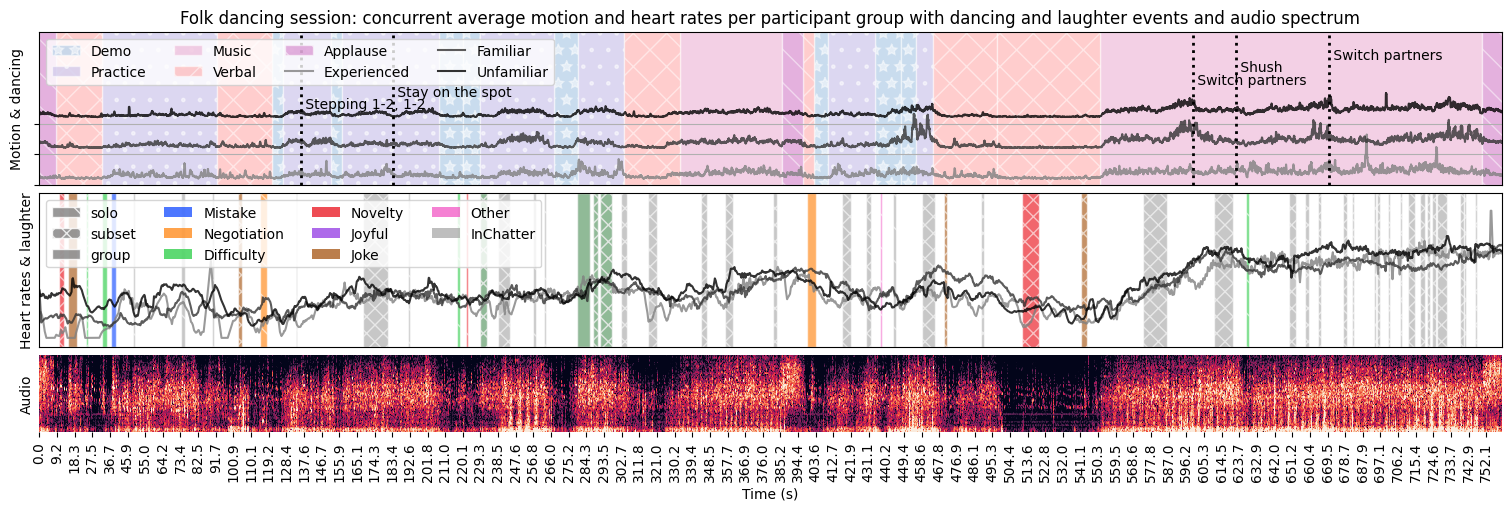

In [28]:
s_time = 0
e_time = 760.0
sect_tags = list(sections.keys())
dancings.loc[:,'TIME'] = dancings.loc[:,'StartTime']


fig3 = plt.figure(constrained_layout=True,figsize=(15,5))
gs = fig3.add_gridspec(5, 3)
axes={}
axes[0] = fig3.add_subplot(gs[0:2, :])
axes[1] = fig3.add_subplot(gs[2:4, :])
axes[2] = fig3.add_subplot(gs[4, :])

ax=axes[0]
for ev in eventType_pallet.keys(): ax.axvspan(-1,-0.5, facecolor=eventType_pallet[ev],hatch=eventType_hatching[ev],edgecolor="w",alpha = 0.5,label=ev)
ax.legend(loc='upper left')
for ev in eventType_pallet.keys():
        e =eventType_code[ev]
        viz.annat_shade(ax,dancings.query('LABEL.str.startswith(@e)'),eventType_pallet[ev],eventType_hatching[ev],0.5)

df_feat =  df_allfeats['ACC_QoM'].copy()
shift_d = 50
for sect_i in range(len(sect_tags)):
    sect = sect_tags[sect_i]
    ax.plot(df_feat[sections[sect]].mean(axis=1)+sect_i*shift_d,color =section_pallet[sect],alpha=0.8,label=sect )
ax.legend(ncol=4,loc='upper left')
ax.set(xlim = [s_time,e_time],ylim = [0,5*shift_d],xticks=[],yticks=[0,shift_d,2*shift_d])
ax.set(yticklabels=[],ylabel='Motion & dancing') 
ax.grid()

ax.set_title('Folk dancing session: concurrent average motion and heart rates per participant group with dancing and laughter events and audio spectrum')

for i,row in instruction_timings.iterrows():
    ax.plot([row['TIME'],row['TIME']],[0,5*shift_d],':k',linewidth=2)
    ax.text(row['TIME'],(2.5*shift_d)+(i*0.4*shift_d),row['LABEL'][4:])
            
ax=axes[1]
A = laughs.loc[:,whats].astype('float').sum()
sub_whats = list(A[A>0].index)
for who in ['solo','subset','group']:
    ax.axvspan(-1,-0.5, facecolor='gray',hatch = who_hatch[who],edgecolor="w",alpha = 0.8,label=who)
for what in sub_whats: ax.axvspan(-1,-0.5, facecolor=what_palette[what],alpha = 0.7,label=what)
ax.legend(ncol=4,loc='upper left')


df_feat =  df_allfeats['normHR1bt'].copy()
for sect_i in range(len(sect_tags)):
    sect = sect_tags[sect_i]
    ax.plot(df_smoothed[sections[sect]].mean(axis=1),color =section_pallet[sect],alpha=0.8,label=sect )
ax.set(xlim = [s_time,e_time],ylim = [-0.3,1.4],xticks=[],yticks=[])
ax.grid()
# ax.legend()
ax.set(yticklabels=[],ylabel='Heart rates & laughter') 
for who in ['subset','few', 'group', 'solo']:
    sub_laughs = laughs.query('Who.str.startswith(@who)')
    for what in whats:
        viz.annat_shade(ax,sub_laughs.query(what+'==1'),what_palette[what],who_hatch[who],0.6)

        
ax=axes[2] 
A = df_allfeats['Audio_cqt'].set_index(np.round(df_allfeats['Audio_cqt'].index,1),drop=True)
chart = sns.heatmap(data=A.loc[s_time:e_time,:].transpose(),cmap="rocket",vmin =-70,vmax=-30,ax=ax,cbar = False,fmt='.1f')
ax.set(yticks=[],ylabel='Audio') 
ax.set_xlabel('Time (s)')

mydpi  = 192
plt.savefig('./Plots/FolkDancing_Full_Annotated_Events_Laughs_Audio.png',bbox_inches = 'tight',dpi = mydpi)

plt.show()

0             After instructor's OK...
1            Instructor laugh response
2           Laugh response trepidation
3    Laugh response social trepidation
4        Laugh at task to find partner
5                Solo laugh in chatter
6                Solo laugh in chatter
7                Solo laugh in chatter
Name: LABEL, dtype: object


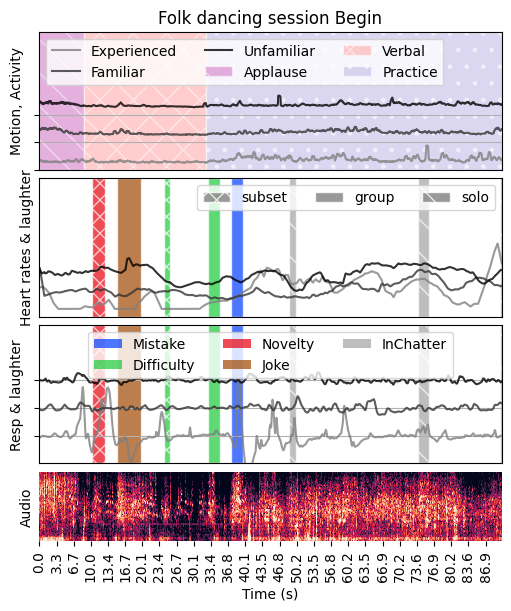

In [29]:
# Colocated {'Begin':0,'seg2': 450, 'Attempt_Spin':256, 'Switch_partner':550 }

seg_tag ='Begin'
s_time = 0 #times[0]
e_time = s_time + 90 #altT[-1]# 3376.0 #760.0 #times[-1]

# sub_events = Event_timings.query('TIME+DURATION>=@s_time and TIME<@e_time')
                      
sub_dancings = dancings.query('TIME+DURATION>=@s_time and TIME<@e_time').copy()
sub_dancings.loc[:,'TIME'] = sub_dancings.loc[:,'StartTime']
sub_eventTypes = list(sub_dancings.LABEL.str[0].unique())

sub_laughs = laughs.query('TIME+DURATION>=@s_time and TIME<@e_time')
print(sub_laughs.LABEL)
A = sub_laughs.loc[:,whats].sum()
sub_whats = list(A[A>0].index)
sub_who = list(sub_laughs.Who.unique())
for who in ['few','Lead']: 
    if who in sub_who: sub_who.remove('few')

fig3 = plt.figure(constrained_layout=True,figsize=(5,6))
gs = fig3.add_gridspec(7, 1)
axes={}
axes[0] = fig3.add_subplot(gs[0:2, :])
axes[1] = fig3.add_subplot(gs[2:4, :])
axes[2] = fig3.add_subplot(gs[4:6, :])
axes[3] = fig3.add_subplot(gs[6, :])

ax=axes[0]

df_feat =  df_allfeats['ACC_QoM'].loc[s_time:e_time,:].copy()
shift_d = 40
for sect_i in range(len(sect_tags)):
    sect = sect_tags[sect_i]
    ax.plot(df_feat[sections[sect]].mean(axis=1)+sect_i*shift_d,color =section_pallet[sect],alpha=0.8,label=sect )
# for ev in sub_eventTypes: ax.axvspan(-1,-0.5, facecolor=eventType_pallet[ev],hatch=eventType_hatching[ev],edgecolor="w",alpha = 0.5,label=ev)
for e in sub_eventTypes:
    ev =code_eventType[e]
    ax.axvspan(-1,-0.5, facecolor=eventType_pallet[ev],hatch=eventType_hatching[ev],edgecolor="w",alpha = 0.5,label=ev)
ax.legend(loc='upper left')
for e in sub_eventTypes:
    ev =code_eventType[e]
    viz.annat_shade(ax,sub_dancings.query('LABEL.str.startswith(@e)'),eventType_pallet[ev],eventType_hatching[ev],0.5)
    
ax.legend(ncol=3,loc='upper left')
ax.set_title('Folk dancing session '+seg_tag)
ax.set(xlim = [s_time,e_time],ylim = [0,5*shift_d],xticks=[],yticks = [0,shift_d,2*shift_d])
ax.set(yticklabels=[],ylabel='Motion, Activity') 
ax.grid()

sub_instructs = instruction_timings.query('TIME>=@s_time and TIME<@e_time')
if len(sub_instructs)>0:
    for i,row in sub_instructs.iterrows():
        ax.plot([row['TIME'],row['TIME']],[0,5*shift_d],':k',linewidth=2)
        ax.text(row['TIME'],(2.5*shift_d)+(i*0.4*shift_d),row['LABEL'][4:])
      

ax=axes[1]

for who in sub_who: ax.axvspan(-1,-0.5, facecolor='gray',hatch = who_hatch[who],edgecolor="w",alpha = 0.8,label=who)
ax.legend(ncol=3,loc='best')
# df_feat = df_allfeats['normHR1bt'].loc[s_time:e_time,:].copy()
for sect_i in range(len(sect_tags)):
    sect = sect_tags[sect_i]
    ax.plot(df_smoothed[sections[sect]].mean(axis=1),color =section_pallet[sect],alpha=0.8,label=sect )
ax.set(yticklabels=[],ylabel='Heart rates & laughter') 
for who in ['subset', 'few', 'group', 'solo']:
    sub_sub_laughs = sub_laughs.query('Who.str.startswith(@who)')
    for what in whats:
        viz.annat_shade(ax,sub_sub_laughs.query(what+'==1'),what_palette[what],who_hatch[who],0.7)
ax.set(xlim = [s_time,e_time],ylim = [-0.3,1.5],xticks=[],yticks=[])
ax.grid()

ax=axes[2]
for what in sub_whats: ax.axvspan(-1,-0.5, facecolor=what_palette[what],alpha = 0.7,label=what)
ax.legend(ncol=3,loc='best')
df_feat = df_allfeats['RespWave'].loc[s_time:e_time,:].copy()
shift_d = 5
for sect_i in range(len(sect_tags)):
    sect = sect_tags[sect_i]
    sectMean = df_feat[sections[sect]].mean(axis=1)
    ax.plot(sectMean - sectMean.mean() +sect_i*shift_d,color =section_pallet[sect],alpha=0.8,label=sect )
# ax.legend()
ax.set(yticklabels=[],ylabel='Resp & laughter') 
for who in ['subset', 'few', 'group', 'solo']:
    sub_sub_laughs = sub_laughs.query('Who.str.startswith(@who)')
    for what in whats:
        viz.annat_shade(ax,sub_sub_laughs.query(what+'==1'),what_palette[what],who_hatch[who],0.7)
ax.set(xlim = [s_time,e_time],ylim = [-shift_d,4*shift_d],xticks=[],yticks = [0,shift_d,2*shift_d])
ax.grid()

ax=axes[3] 

A = df_allfeats['Audio_cqt'].set_index(np.round(df_allfeats['Audio_cqt'].index,1),drop=True)
chart = sns.heatmap(data=A.loc[s_time:e_time,:].transpose(),cmap="rocket",vmin =-70,vmax=-30,ax=ax,cbar = False,fmt='.1f')
ax.set(yticks=[],ylabel='Audio') 
ax.set_xlabel('Time (s)')

mydpi  = 192
plt.savefig('./Plots/Folk_'+seg_tag+'_'+piece+'_Cascade_HR_QoM_audio.png',bbox_inches = 'tight',dpi = mydpi)
plt.show()

# Laugh counts 

In [30]:
Laugh_Counts = pd.DataFrame(index = whats, columns = events_types,data = 0)
for i,row in dancings.iterrows():
    s_time = row['StartTime']
    e_time = row['EndTime']
    sub_laughs = laughs.query('TIME+DURATION>=@s_time and TIME<@e_time')
    Laugh_Counts.loc[whats,row['Trial_Type']]+=sub_laughs.loc[:,whats].sum()

Laugh_Counts.columns

Index(['Demo', 'Practice', 'Music', 'Verbal', 'Applause'], dtype='object')

In [31]:
print(Laugh_Counts[['Demo', 'Practice', 'Music', 'Verbal']].to_latex())

\begin{tabular}{lrrrr}
\toprule
 & Demo & Practice & Music & Verbal \\
\midrule
Mistake & 0 & 1 & 0 & 0 \\
Negotiation & 1 & 0 & 0 & 2 \\
Difficulty & 2 & 5 & 1 & 1 \\
Novelty & 1 & 0 & 0 & 2 \\
Joyful & 0 & 0 & 0 & 1 \\
Joke & 0 & 0 & 0 & 4 \\
Other & 1 & 0 & 0 & 0 \\
InChatter & 2 & 17 & 22 & 4 \\
\bottomrule
\end{tabular}



In [34]:
s_time = 0
e_time = 760.0
Laugh_Counts = pd.DataFrame(index = whats)


whos = ['group']
sub_laughs = laughs.query('TIME+DURATION>=@s_time and TIME<@e_time and Who in @whos')
B = (sub_laughs.loc[:,whats]>0.75).sum()
Laugh_Counts.loc[:,'Group'] = B
# C

whos = ['few','subset']
sub_laughs = laughs.query('TIME+DURATION>=@s_time and TIME<@e_time and Who in @whos')
B = (sub_laughs.loc[:,whats]>0.75).sum()
Laugh_Counts.loc[:,'Subset'] = B

whos = ['participant', 'solo']
sub_laughs = laughs.query('TIME+DURATION>=@s_time and TIME<@e_time and Who in @whos')
B = (sub_laughs.loc[:,whats]>0.75).sum()
Laugh_Counts.loc[:,'Solo'] = B

Laugh_Counts

,Group,Subset,Solo
Mistake,1,0,0
Negotiation,1,0,1
Difficulty,2,4,2
Novelty,0,2,1
Joyful,0,0,0
Joke,1,3,0
Other,0,0,1
InChatter,1,33,8


In [35]:
print(Laugh_Counts.to_latex())

\begin{tabular}{lrrr}
\toprule
 & Group & Subset & Solo \\
\midrule
Mistake & 1 & 0 & 0 \\
Negotiation & 1 & 0 & 1 \\
Difficulty & 2 & 4 & 2 \\
Novelty & 0 & 2 & 1 \\
Joyful & 0 & 0 & 0 \\
Joke & 1 & 3 & 0 \\
Other & 0 & 0 & 1 \\
InChatter & 1 & 33 & 8 \\
\bottomrule
\end{tabular}

